# AETS Real-Data Development Benchmark

# **AETS — Adaptive Empirical Tail Scan**

AETS is a **single standalone, non-ensemble outlier detector**. It does not use scores from IForest, ECOD, COPOD, PCA, or any other detector internally.

For observation \(i\) and feature \(j\), define the empirical rank coordinate

\[
U_{ij}=\frac{R_{ij}-0.5}{n},
\]

and the two-sided empirical tail probability

\[
p_{ij}=2\min\{U_{ij},1-U_{ij}\}.
\]

Sort these probabilities:

\[
p_{i(1)}\le \cdots \le p_{i(d)}.
\]

For \(m=1,\ldots,\lfloor d/2\rfloor\), let \(q_m=m/d\) and define the signed root Bernoulli likelihood-ratio contrast

\[
L_{im}
=
\operatorname{sign}\{q_m-p_{i(m)}\}
\sqrt{
2d\,D(q_m\Vert p_{i(m)})
},
\]

where

\[
D(q\Vert p)=q\log(q/p)+(1-q)\log((1-q)/(1-p)).
\]

The final score is

\[
\boxed{
S_i^{\mathrm{AETS}}=\max_m L_{im}.
}
\]

The maximizing index \(m_i^\star\) estimates how many features are contributing to the strongest tail signal.

AETS is parameter-free with respect to anomaly scoring, deterministic, invariant to strictly monotone feature transformations, and uses labels only for evaluation.


In [1]:
# Run once if needed:
# %pip install -U numpy pandas scipy scikit-learn pyod h5py


## 1. Imports and settings

In [2]:
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.io import loadmat, arff
from scipy.stats import rankdata
from scipy.special import xlogy

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score

from IPython.display import display

DATA_DIR = Path.cwd()
OUTPUT_DIR = DATA_DIR / "aets_results"
OUTPUT_DIR.mkdir(exist_ok=True)

SCALING = "robust"
SEED = 42

# External benchmarks only.
PYOD_CONTAMINATION = 0.10
IFOREST_N_ESTIMATORS = 200
KNN_N_NEIGHBORS = 20
LOF_N_NEIGHBORS = 20
ABOD_N_NEIGHBORS = 5
CBLOF_N_CLUSTERS = 8
FB_N_ESTIMATORS = 10
LODA_N_RANDOM_CUTS = 100

BENCHMARK_METHODS = [
    "COPOD",
    "ECOD",
    "HBOS",
    "IForest",
    "KNN",
    "LOF",
    "PCA",
    "OCSVM",
    "ABOD",
    "CBLOF",
    "FeatureBagging",
    "LODA",
]

POSITIVE_LABEL = None
ARFF_LABEL_COL = None
MAT_X_KEY = None
MAT_Y_KEY = None
ROW_LIMIT = None

print("Current working folder:")
print(DATA_DIR)
print("\nOutput folder:")
print(OUTPUT_DIR)


Current working folder:
C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets

Output folder:
C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results


## 2. Read `.mat` and `.arff` files in the current folder only

In [3]:
def discover_current_folder_datasets(folder: Path):
    folder = Path(folder)

    return sorted(
        [
            p for p in folder.iterdir()
            if p.is_file()
            and p.suffix.lower() in {".mat", ".arff"}
        ],
        key=lambda p: p.name.lower(),
    )


dataset_files = discover_current_folder_datasets(DATA_DIR)

print(
    f"Found {len(dataset_files)} .mat/.arff file(s) "
    "directly in the CURRENT folder:\n"
)

for p in dataset_files:
    print(" ", p.name)

if not dataset_files:
    raise FileNotFoundError(
        "No .mat or .arff files were found directly in:\n"
        f"{DATA_DIR}\n\n"
        "Put the notebook in the dataset folder or start Jupyter from that folder."
    )


Found 19 .mat/.arff file(s) directly in the CURRENT folder:

  ALOI_withoutdupl_norm.arff
  arrhythmia.mat
  Arrhythmia_withoutdupl_norm_46.arff
  breastw.mat
  cardio.mat
  Cardiotocography_withoutdupl_norm_10_v10.arff
  glass.mat
  KDDCup99_original.arff
  mammography.mat
  musk.mat
  PageBlocks_withoutdupl_norm_05_v10.arff
  pendigits.mat
  seismic-bumps.arff
  shuttle.mat
  Shuttle_withoutdupl_norm_v10.arff
  thyroid.mat
  vertebral.mat
  Wilt_withoutdupl_norm_02_v10.arff
  wine.mat


## 3. Dataset loading and preprocessing

In [4]:
POSITIVE_TOKENS = {
    "1", "true", "yes", "y",
    "outlier", "outliers",
    "anomaly", "anomalous",
    "abnormal", "positive",
    "fraud", "attack",
}

NEGATIVE_TOKENS = {
    "0", "false", "no", "n",
    "normal", "normality",
    "inlier", "inliers",
    "negative", "benign",
}

LABEL_NAMES = [
    "y", "label", "labels", "class", "target",
    "outlier", "anomaly", "is_outlier", "is_anomaly",
    "ground_truth", "groundtruth",
]

X_NAMES = [
    "x", "data", "features", "feature",
    "samples", "observations",
]


def _decode(v):
    if isinstance(v, (bytes, np.bytes_)):
        return v.decode("utf-8", errors="ignore")
    return v


def _to_1d(y):
    if sparse.issparse(y):
        y = y.toarray()

    y = np.asarray(y)
    y = np.squeeze(y)

    return y.reshape(-1)


def _to_2d(X):
    if sparse.issparse(X):
        X = X.toarray()

    X = np.asarray(X)
    X = np.squeeze(X)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    if X.ndim != 2:
        raise ValueError(
            f"Feature matrix must be 2D after squeezing; got {X.shape}"
        )

    return X


def encode_binary_labels(y, positive_label=None):
    raw = np.asarray(
        [_decode(v) for v in _to_1d(y)],
        dtype=object,
    )

    if pd.isna(raw).any():
        raise ValueError("Label vector contains missing values.")

    if positive_label is not None:
        target = str(positive_label).strip().lower()

        tokens = np.asarray(
            [str(v).strip().lower() for v in raw]
        )

        out = (tokens == target).astype(int)

        if out.sum() == 0 or out.sum() == len(out):
            raise ValueError(
                f"POSITIVE_LABEL={positive_label!r} did not produce two classes. "
                f"Observed labels={np.unique(tokens).tolist()}"
            )

        return out

    numeric = pd.to_numeric(
        pd.Series(raw),
        errors="coerce",
    )

    if numeric.notna().all():
        vals = numeric.to_numpy(float)
        uniq = np.unique(vals)

        if len(uniq) != 2:
            raise ValueError(
                f"Expected binary labels; found {uniq.tolist()}"
            )

        if np.allclose(np.sort(uniq), [0, 1]):
            return (vals == 1).astype(int)

        if np.allclose(np.sort(uniq), [-1, 1]):
            return (vals == -1).astype(int)

        counts = {
            u: int(np.sum(vals == u))
            for u in uniq
        }

        pos = min(counts, key=counts.get)

        warnings.warn(
            f"Unrecognized numeric labels {uniq.tolist()}; "
            f"treating minority class {pos!r} as anomaly. "
            "Set POSITIVE_LABEL to override."
        )

        return (vals == pos).astype(int)

    tokens = np.asarray(
        [str(v).strip().lower() for v in raw]
    )

    uniq = np.unique(tokens)

    if len(uniq) != 2:
        raise ValueError(
            f"Expected binary labels; found {uniq.tolist()}"
        )

    pos_hits = [
        u for u in uniq
        if u in POSITIVE_TOKENS
    ]

    neg_hits = [
        u for u in uniq
        if u in NEGATIVE_TOKENS
    ]

    if len(pos_hits) == 1 and len(neg_hits) == 1:
        return (tokens == pos_hits[0]).astype(int)

    counts = {
        u: int(np.sum(tokens == u))
        for u in uniq
    }

    pos = min(counts, key=counts.get)

    warnings.warn(
        f"Unrecognized string labels {uniq.tolist()}; "
        f"treating minority class {pos!r} as anomaly. "
        "Set POSITIVE_LABEL to override."
    )

    return (tokens == pos).astype(int)


def load_mat_file(path: Path):
    try:
        data = loadmat(path)

    except (NotImplementedError, ValueError, OSError):
        try:
            import h5py
        except ImportError as e:
            raise ImportError(
                "Install h5py to read MATLAB v7.3 files."
            ) from e

        data = {}

        with h5py.File(path, "r") as f:
            for key in f.keys():
                try:
                    data[key] = np.array(f[key])
                except Exception:
                    pass

    keys = [
        k for k in data
        if not k.startswith("__")
    ]

    lower = {
        k.lower(): k
        for k in keys
    }

    if MAT_X_KEY is not None and MAT_Y_KEY is not None:
        if MAT_X_KEY not in data or MAT_Y_KEY not in data:
            raise KeyError(
                f"Requested MAT keys not found. Available keys: {keys}"
            )

        X = _to_2d(data[MAT_X_KEY])
        y = _to_1d(data[MAT_Y_KEY])

    else:
        xkey = next(
            (lower[c] for c in X_NAMES if c in lower),
            None,
        )

        ykey = next(
            (lower[c] for c in LABEL_NAMES if c in lower),
            None,
        )

        if xkey is not None and ykey is not None:
            X = _to_2d(data[xkey])
            y = _to_1d(data[ykey])

        else:
            vectors = []
            matrices = []

            for k in keys:
                try:
                    arr = (
                        data[k].toarray()
                        if sparse.issparse(data[k])
                        else np.asarray(data[k])
                    )

                    sq = np.squeeze(arr)

                except Exception:
                    continue

                if sq.ndim == 1 and sq.size >= 2:
                    vectors.append(
                        (k, sq.reshape(-1))
                    )

                elif sq.ndim == 2:
                    matrices.append(
                        (k, _to_2d(sq))
                    )

            y_candidates = []

            for k, v in vectors:
                try:
                    if len(
                        pd.unique(
                            pd.Series(v).dropna()
                        )
                    ) == 2:
                        y_candidates.append(
                            (k, v)
                        )
                except Exception:
                    pass

            best = None

            for yk, yv in y_candidates:
                for xk, Xm in matrices:
                    for Xt in (Xm, Xm.T):

                        if (
                            Xt.shape[0] == len(yv)
                            and Xt.shape[1] >= 1
                        ):
                            score = (
                                Xt.shape[0]
                                * Xt.shape[1]
                            )

                            if xk.lower() in X_NAMES:
                                score *= 10

                            if yk.lower() in LABEL_NAMES:
                                score *= 10

                            if (
                                best is None
                                or score > best[0]
                            ):
                                best = (
                                    score,
                                    Xt,
                                    yv,
                                    xk,
                                    yk,
                                )

            if best is None:
                shapes = {
                    k: np.asarray(data[k]).shape
                    for k in keys
                    if hasattr(data[k], "shape")
                }

                raise ValueError(
                    f"Could not infer X/y from {path.name}. "
                    f"Arrays={shapes}. "
                    "Set MAT_X_KEY and MAT_Y_KEY if needed."
                )

            _, X, y, xkey, ykey = best

            print(
                f"    inferred MAT keys: "
                f"X={xkey!r}, y={ykey!r}"
            )

    if (
        X.shape[0] != len(y)
        and X.shape[1] == len(y)
    ):
        X = X.T

    if X.shape[0] != len(y):
        raise ValueError(
            f"X shape {X.shape} does not match y length {len(y)}"
        )

    return (
        X.astype(float),
        encode_binary_labels(
            y,
            POSITIVE_LABEL,
        ),
    )


def load_arff_file(path: Path):
    records, _ = arff.loadarff(path)

    df = pd.DataFrame(records)

    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].map(_decode)

            df[c] = df[c].replace(
                {
                    "?": np.nan,
                    "": np.nan,
                }
            )

    if ARFF_LABEL_COL is not None:
        if ARFF_LABEL_COL not in df.columns:
            raise KeyError(
                f"ARFF_LABEL_COL={ARFF_LABEL_COL!r} not found. "
                f"Columns={list(df.columns)}"
            )

        label_col = ARFF_LABEL_COL

    else:
        lower = {
            str(c).lower(): c
            for c in df.columns
        }

        label_col = next(
            (
                lower[c]
                for c in LABEL_NAMES
                if c in lower
            ),
            None,
        )

        if label_col is None:
            last = df.columns[-1]

            if df[last].nunique(dropna=True) == 2:
                label_col = last

            else:
                binary_cols = [
                    c for c in df.columns
                    if df[c].nunique(dropna=True) == 2
                ]

                if not binary_cols:
                    raise ValueError(
                        f"Could not infer label column in {path.name}. "
                        "Set ARFF_LABEL_COL."
                    )

                label_col = binary_cols[-1]

    raw_y = df[label_col].to_numpy()

    Xdf = df.drop(
        columns=[label_col]
    ).copy()

    categorical = []

    for c in Xdf.columns:

        if pd.api.types.is_numeric_dtype(
            Xdf[c]
        ):
            Xdf[c] = pd.to_numeric(
                Xdf[c],
                errors="coerce",
            )

        else:
            num = pd.to_numeric(
                Xdf[c],
                errors="coerce",
            )

            denom = max(
                int(Xdf[c].notna().sum()),
                1,
            )

            if (
                num.notna().sum()
                / denom
                >= 0.98
            ):
                Xdf[c] = num

            else:
                categorical.append(c)

    if categorical:
        Xdf = pd.get_dummies(
            Xdf,
            columns=categorical,
            dummy_na=True,
            dtype=float,
        )

    X = Xdf.to_numpy(float)

    y = encode_binary_labels(
        raw_y,
        POSITIVE_LABEL,
    )

    return X, y


def load_dataset(path: Path):
    suffix = path.suffix.lower()

    if suffix == ".mat":
        return load_mat_file(path)

    if suffix == ".arff":
        return load_arff_file(path)

    raise ValueError(
        f"Unsupported file type: {suffix}"
    )


def preprocess_X(X, scaling="robust"):
    X = np.asarray(
        X,
        dtype=float,
    )

    X[~np.isfinite(X)] = np.nan

    usable = np.any(
        np.isfinite(X),
        axis=0,
    )

    X = X[:, usable]

    if X.shape[1] == 0:
        raise ValueError(
            "No usable feature columns."
        )

    X = SimpleImputer(
        strategy="median"
    ).fit_transform(X)

    spread = (
        np.max(X, axis=0)
        - np.min(X, axis=0)
    )

    X = X[:, spread > 0]

    if X.shape[1] == 0:
        raise ValueError(
            "All features are constant."
        )

    if scaling == "robust":
        X = RobustScaler().fit_transform(X)

    elif scaling == "standard":
        X = StandardScaler().fit_transform(X)

    elif scaling == "none":
        pass

    else:
        raise ValueError(
            f"Unknown scaling={scaling!r}"
        )

    return np.asarray(
        X,
        dtype=np.float64,
    )


## 4. AETS implementation

In [5]:
def empirical_two_sided_tail_pvalues(X):
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    P = np.empty((n, d), dtype=float)

    for j in range(d):
        ranks = rankdata(
            X[:, j],
            method="average",
        )
        u = (ranks - 0.5) / n
        p = 2.0 * np.minimum(
            u,
            1.0 - u,
        )
        P[:, j] = np.clip(
            p,
            1.0 / n,
            1.0,
        )

    return P


def bernoulli_kl(q, p):
    q = np.asarray(q, dtype=float)
    p = np.asarray(p, dtype=float)

    eps = np.finfo(float).eps
    q = np.clip(q, eps, 1.0 - eps)
    p = np.clip(p, eps, 1.0 - eps)

    return (
        xlogy(q, q / p)
        + xlogy(
            1.0 - q,
            (1.0 - q) / (1.0 - p),
        )
    )


def compute_aets(X):
    start = time.perf_counter()

    X = np.asarray(
        X,
        dtype=float,
    )

    n, d = X.shape

    if n < 3:
        raise ValueError(
            "AETS requires at least 3 observations."
        )

    P = empirical_two_sided_tail_pvalues(
        X
    )

    P_sorted = np.sort(
        P,
        axis=1,
    )

    if d == 1:
        score = -np.log(
            P_sorted[:, 0]
        )
        winning_m = np.ones(
            n,
            dtype=int,
        )
        winning_p = P_sorted[:, 0]

    else:
        m_max = max(
            1,
            d // 2,
        )

        m = np.arange(
            1,
            m_max + 1,
            dtype=float,
        )

        q = m / d

        observed = P_sorted[
            :,
            :m_max
        ]

        kl = bernoulli_kl(
            q[None, :],
            observed,
        )

        direction = np.sign(
            q[None, :]
            - observed
        )

        scan = (
            direction
            * np.sqrt(
                np.maximum(
                    2.0 * d * kl,
                    0.0,
                )
            )
        )

        winning_idx = np.argmax(
            scan,
            axis=1,
        )

        score = scan[
            np.arange(n),
            winning_idx,
        ]

        winning_m = winning_idx + 1

        winning_p = observed[
            np.arange(n),
            winning_idx,
        ]

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "score": np.asarray(score, dtype=float),
        "winning_m": np.asarray(winning_m, dtype=int),
        "winning_p": np.asarray(winning_p, dtype=float),
        "min_p": np.min(P, axis=1),
        "time_sec": float(elapsed),
    }


## 5. External benchmark detectors

In [6]:
def get_benchmark_scores(
    Z,
    requested=BENCHMARK_METHODS,
    seed=SEED,
):
    """
    Fit established unsupervised detectors.

    Returns
    -------
    scores : dict[str, ndarray]
    times  : dict[str, float]
    failures : list[dict]

    Ground-truth labels are not passed to any detector.
    """
    try:
        from pyod.models.copod import COPOD
        from pyod.models.ecod import ECOD
        from pyod.models.hbos import HBOS
        from pyod.models.iforest import IForest
        from pyod.models.knn import KNN
        from pyod.models.lof import LOF
        from pyod.models.pca import PCA as PyODPCA
        from pyod.models.ocsvm import OCSVM
        from pyod.models.abod import ABOD
        from pyod.models.cblof import CBLOF
        from pyod.models.feature_bagging import FeatureBagging
        from pyod.models.loda import LODA

    except ImportError as exc:
        raise ImportError(
            "PyOD is required for this benchmark. Run: pip install -U pyod"
        ) from exc

    requested = set(requested)
    n, d = Z.shape

    k_knn = max(
        1,
        min(
            KNN_N_NEIGHBORS,
            n - 1,
        ),
    )

    k_lof = max(
        2,
        min(
            LOF_N_NEIGHBORS,
            n - 1,
        ),
    )

    k_abod = max(
        2,
        min(
            ABOD_N_NEIGHBORS,
            n - 1,
        ),
    )

    cblof_clusters = max(
        2,
        min(
            CBLOF_N_CLUSTERS,
            n - 1,
        ),
    )

    model_builders = {
        "COPOD": lambda: COPOD(
            contamination=PYOD_CONTAMINATION,
        ),

        "ECOD": lambda: ECOD(
            contamination=PYOD_CONTAMINATION,
        ),

        "HBOS": lambda: HBOS(
            contamination=PYOD_CONTAMINATION,
        ),

        "IForest": lambda: IForest(
            contamination=PYOD_CONTAMINATION,
            n_estimators=IFOREST_N_ESTIMATORS,
            random_state=seed,
            n_jobs=-1,
        ),

        "KNN": lambda: KNN(
            contamination=PYOD_CONTAMINATION,
            n_neighbors=k_knn,
            method="largest",
            n_jobs=-1,
        ),

        "LOF": lambda: LOF(
            contamination=PYOD_CONTAMINATION,
            n_neighbors=k_lof,
            n_jobs=-1,
        ),

        "PCA": lambda: PyODPCA(
            contamination=PYOD_CONTAMINATION,
        ),

        "OCSVM": lambda: OCSVM(
            contamination=PYOD_CONTAMINATION,
            kernel="rbf",
            gamma="auto",
            nu=0.5,
        ),

        # FastABOD is used consistently for scalability.
        "ABOD": lambda: ABOD(
            contamination=PYOD_CONTAMINATION,
            n_neighbors=k_abod,
            method="fast",
            n_jobs=-1,
        ),

        "CBLOF": lambda: CBLOF(
            contamination=PYOD_CONTAMINATION,
            n_clusters=cblof_clusters,
            random_state=seed,
            use_weights=False,
        ),

        # External benchmark only. LOF is the base estimator.
        "FeatureBagging": lambda: FeatureBagging(
            base_estimator=LOF(
                contamination=PYOD_CONTAMINATION,
                n_neighbors=k_lof,
                n_jobs=-1,
            ),
            n_estimators=FB_N_ESTIMATORS,
            contamination=PYOD_CONTAMINATION,
            n_jobs=-1,
            random_state=seed,
            combination="average",
        ),

        "LODA": lambda: LODA(
            contamination=PYOD_CONTAMINATION,
            n_bins=10,
            n_random_cuts=LODA_N_RANDOM_CUTS,
            random_state=seed,
        ),
    }

    scores = {}
    times = {}
    failures = []

    for name in BENCHMARK_METHODS:
        if name not in requested:
            continue

        print(
            f"    fitting {name:15s} ... ",
            end="",
            flush=True,
        )

        start = time.perf_counter()

        try:
            model = model_builders[name]()
            model.fit(Z)

            score = np.asarray(
                model.decision_scores_,
                dtype=float,
            ).reshape(-1)

            if len(score) != n:
                raise ValueError(
                    f"score length {len(score)} != n={n}"
                )

            elapsed = time.perf_counter() - start

            scores[name] = score
            times[name] = elapsed

            print(
                f"done ({elapsed:.2f}s)"
            )

        except Exception as exc:
            elapsed = time.perf_counter() - start

            failures.append({
                "method": name,
                "error_type": type(exc).__name__,
                "error": str(exc),
                "time_sec": elapsed,
            })

            print(
                f"FAILED: {type(exc).__name__}: {exc}"
            )

    return scores, times, failures


## 6. Evaluation utilities

In [7]:
def evaluate_score(
    y,
    score,
):
    score = np.asarray(
        score,
        dtype=float,
    )

    if not np.all(
        np.isfinite(score)
    ):
        finite = score[
            np.isfinite(score)
        ]

        fill = (
            np.median(finite)
            if len(finite)
            else 0.0
        )

        score = np.where(
            np.isfinite(score),
            score,
            fill,
        )

    ap = average_precision_score(
        y,
        score,
    )

    roc = roc_auc_score(
        y,
        score,
    )

    return float(ap), float(roc)


def safe_dataset_name(path: Path):
    return (
        path.name
        .replace(" ", "_")
        .replace(".", "_")
    )


def aggregate_results_table(
    results,
):
    work = results.copy()

    work["AP_rank"] = (
        work
        .groupby("dataset")["AP"]
        .rank(
            ascending=False,
            method="average",
        )
    )

    work["ROC_rank"] = (
        work
        .groupby("dataset")["ROC_AUC"]
        .rank(
            ascending=False,
            method="average",
        )
    )

    return (
        work
        .groupby(
            "method",
            as_index=False,
        )
        .agg(
            datasets=(
                "dataset",
                "nunique",
            ),
            mean_AP=(
                "AP",
                "mean",
            ),
            median_AP=(
                "AP",
                "median",
            ),
            mean_ROC_AUC=(
                "ROC_AUC",
                "mean",
            ),
            mean_AP_rank=(
                "AP_rank",
                "mean",
            ),
            mean_ROC_rank=(
                "ROC_rank",
                "mean",
            ),
            mean_time_sec=(
                "time_sec",
                "mean",
            ),
            median_time_sec=(
                "time_sec",
                "median",
            ),
            total_time_sec=(
                "time_sec",
                "sum",
            ),
        )
        .sort_values(
            [
                "mean_AP_rank",
                "mean_AP",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .reset_index(
            drop=True
        )
    )


## 7. Run the real-data development benchmark

In [8]:
dataset_files = discover_current_folder_datasets(
    DATA_DIR
)

print(
    f"Running {len(dataset_files)} dataset(s) "
    "from the CURRENT folder only."
)

for p in dataset_files:
    print(" ", p.name)

if not dataset_files:
    raise FileNotFoundError(
        "No .mat/.arff files found directly in the current folder."
    )

score_dir = OUTPUT_DIR / "scores"
score_dir.mkdir(exist_ok=True)

rows = []
errors = []
method_failures = []
aets_diagnostics = []

for index, path in enumerate(
    dataset_files,
    start=1,
):
    dataset = safe_dataset_name(
        path
    )

    print(
        "\n"
        + "=" * 106
    )
    print(
        f"[{index}/{len(dataset_files)}] "
        f"{path.name}"
    )

    try:
        X, y = load_dataset(
            path
        )

        if (
            ROW_LIMIT is not None
            and len(X) > ROW_LIMIT
        ):
            X = X[:ROW_LIMIT]
            y = y[:ROW_LIMIT]

        Z = preprocess_X(
            X,
            SCALING,
        )

        n, d = Z.shape
        n_outliers = int(
            y.sum()
        )
        contamination = (
            n_outliers / n
        )

        print(
            f"  n={n:,}, d={d:,}, "
            f"outliers={n_outliers:,} "
            f"({contamination:.2%})"
        )

        scores = {}
        times = {}

        aets = compute_aets(
            Z
        )

        scores["AETS"] = aets[
            "score"
        ]
        times["AETS"] = aets[
            "time_sec"
        ]

        aets_diagnostics.append({
            "dataset": dataset,
            "n": n,
            "d": d,
            "mean_winning_m": float(
                np.mean(
                    aets["winning_m"]
                )
            ),
            "median_winning_m": float(
                np.median(
                    aets["winning_m"]
                )
            ),
            "mean_winning_fraction": float(
                np.mean(
                    aets["winning_m"] / d
                )
            ),
            "time_sec": aets[
                "time_sec"
            ],
        })

        print(
            "  AETS: "
            f"median winning m="
            f"{np.median(aets['winning_m']):.1f}, "
            f"time={aets['time_sec']:.3f}s"
        )

        baseline_scores, baseline_times, failures = (
            get_benchmark_scores(
                Z,
                requested=BENCHMARK_METHODS,
                seed=SEED,
            )
        )

        for method, score in baseline_scores.items():
            scores[method] = score
            times[method] = baseline_times[
                method
            ]

        for item in failures:
            method_failures.append({
                "dataset": dataset,
                "file": path.name,
                **item,
            })

        per_dataset_scores = pd.DataFrame({
            "y": y,
            "AETS_winning_m": aets[
                "winning_m"
            ],
            "AETS_winning_p": aets[
                "winning_p"
            ],
            "AETS_min_p": aets[
                "min_p"
            ],
        })

        for method, score in scores.items():
            ap, roc = evaluate_score(
                y,
                score,
            )

            per_dataset_scores[
                method
            ] = score

            runtime = times.get(
                method,
                np.nan,
            )

            rows.append({
                "dataset": dataset,
                "file": path.name,
                "n": n,
                "d": d,
                "n_outliers": n_outliers,
                "outlier_fraction": contamination,
                "method": method,
                "AP": ap,
                "ROC_AUC": roc,
                "time_sec": runtime,
            })

            print(
                f"  {method:15s} "
                f"AP={ap:.4f}  "
                f"ROC-AUC={roc:.4f}  "
                f"time={runtime:.3f}s"
            )

        per_dataset_scores.to_csv(
            score_dir
            / f"{dataset}_scores.csv",
            index=False,
        )

    except Exception as exc:
        print(
            f"  DATASET ERROR: "
            f"{type(exc).__name__}: "
            f"{exc}"
        )

        errors.append({
            "dataset": dataset,
            "file": path.name,
            "error_type": type(exc).__name__,
            "error": str(exc),
        })

results = pd.DataFrame(rows)
errors_df = pd.DataFrame(errors)
method_failures_df = pd.DataFrame(
    method_failures
)
aets_diagnostics_df = pd.DataFrame(
    aets_diagnostics
)

results.to_csv(
    OUTPUT_DIR / "results_long.csv",
    index=False,
)
errors_df.to_csv(
    OUTPUT_DIR / "dataset_errors.csv",
    index=False,
)
method_failures_df.to_csv(
    OUTPUT_DIR / "method_failures.csv",
    index=False,
)
aets_diagnostics_df.to_csv(
    OUTPUT_DIR / "AETS_diagnostics.csv",
    index=False,
)

if len(results):
    aggregate = aggregate_results_table(
        results
    )

    aggregate.to_csv(
        OUTPUT_DIR / "aggregate_results.csv",
        index=False,
    )

    print(
        "\n"
        + "=" * 106
    )
    print(
        "AGGREGATE RESULTS"
    )
    display(
        aggregate
    )

    print(
        "\nAETS DIAGNOSTICS"
    )
    display(
        aets_diagnostics_df
    )
else:
    aggregate = pd.DataFrame()
    print(
        "No dataset completed successfully."
    )


Running 19 dataset(s) from the CURRENT folder only.
  ALOI_withoutdupl_norm.arff
  arrhythmia.mat
  Arrhythmia_withoutdupl_norm_46.arff
  breastw.mat
  cardio.mat
  Cardiotocography_withoutdupl_norm_10_v10.arff
  glass.mat
  KDDCup99_original.arff
  mammography.mat
  musk.mat
  PageBlocks_withoutdupl_norm_05_v10.arff
  pendigits.mat
  seismic-bumps.arff
  shuttle.mat
  Shuttle_withoutdupl_norm_v10.arff
  thyroid.mat
  vertebral.mat
  Wilt_withoutdupl_norm_02_v10.arff
  wine.mat

[1/19] ALOI_withoutdupl_norm.arff
  n=49,534, d=28, outliers=1,508 (3.04%)
  AETS: median winning m=7.0, time=0.157s
    fitting COPOD           ... done (0.77s)
    fitting ECOD            ... done (0.27s)
    fitting HBOS            ... done (2.62s)
    fitting IForest         ... done (1.39s)
    fitting KNN             ... done (3.83s)
    fitting LOF             ... done (3.06s)
    fitting PCA             ... done (0.10s)
    fitting OCSVM           ... done (256.37s)
    fitting ABOD            ... done 

C:\Users\jzhou\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


done (0.06s)
  AETS            AP=0.4698  ROC-AUC=0.7914  time=0.020s
  COPOD           AP=0.4612  ROC-AUC=0.7998  time=0.015s
  ECOD            AP=0.4662  ROC-AUC=0.8052  time=0.014s
  HBOS            AP=0.4457  ROC-AUC=0.7978  time=0.052s
  IForest         AP=0.4956  ROC-AUC=0.8119  time=0.330s
  KNN             AP=0.4923  ROC-AUC=0.8015  time=0.021s
  LOF             AP=0.2189  ROC-AUC=0.6144  time=0.017s
  PCA             AP=0.3951  ROC-AUC=0.7748  time=0.149s
  OCSVM           AP=0.3543  ROC-AUC=0.7876  time=0.039s
  ABOD            AP=0.3411  ROC-AUC=0.7915  time=0.084s
  CBLOF           AP=0.3697  ROC-AUC=0.7825  time=0.016s
  FeatureBagging  AP=0.2572  ROC-AUC=0.6702  time=0.165s
  LODA            AP=0.4417  ROC-AUC=0.7442  time=0.062s

[3/19] Arrhythmia_withoutdupl_norm_46.arff
  n=450, d=260, outliers=206 (45.78%)
  AETS: median winning m=3.0, time=0.043s
    fitting COPOD           ... done (0.02s)
    fitting ECOD            ... done (0.01s)
    fitting HBOS            ... 

C:\Users\jzhou\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


done (0.07s)
  AETS            AP=0.7367  ROC-AUC=0.7355  time=0.043s
  COPOD           AP=0.7617  ROC-AUC=0.7560  time=0.015s
  ECOD            AP=0.7596  ROC-AUC=0.7518  time=0.015s
  HBOS            AP=0.7623  ROC-AUC=0.7473  time=0.051s
  IForest         AP=0.7620  ROC-AUC=0.7494  time=0.324s
  KNN             AP=0.7772  ROC-AUC=0.7699  time=0.020s
  LOF             AP=0.7606  ROC-AUC=0.7661  time=0.016s
  PCA             AP=0.7101  ROC-AUC=0.7317  time=0.130s
  OCSVM           AP=0.7621  ROC-AUC=0.7544  time=0.032s
  ABOD            AP=0.6889  ROC-AUC=0.7073  time=0.088s
  CBLOF           AP=0.7659  ROC-AUC=0.7673  time=0.017s
  FeatureBagging  AP=0.7535  ROC-AUC=0.7577  time=0.169s
  LODA            AP=0.6906  ROC-AUC=0.6874  time=0.068s

[4/19] breastw.mat
  n=683, d=9, outliers=239 (34.99%)
  AETS: median winning m=4.0, time=0.002s
    fitting COPOD           ... done (0.00s)
    fitting ECOD            ... done (0.00s)
    fitting HBOS            ... done (0.00s)
    fitting I

...

C:\Users\jzhou\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


done (0.27s)
    fitting LODA            ... done (0.02s)
  AETS            AP=0.2184  ROC-AUC=0.7340  time=0.001s
  COPOD           AP=0.3612  ROC-AUC=0.8672  time=0.001s
  ECOD            AP=0.1907  ROC-AUC=0.7328  time=0.002s
  HBOS            AP=0.3940  ROC-AUC=0.9076  time=0.005s
  IForest         AP=0.1852  ROC-AUC=0.7815  time=0.301s
  KNN             AP=0.4983  ROC-AUC=0.9429  time=0.025s
  LOF             AP=0.3081  ROC-AUC=0.9042  time=0.027s
  PCA             AP=0.2555  ROC-AUC=0.8210  time=0.002s
  OCSVM           AP=0.2265  ROC-AUC=0.8050  time=0.002s
  ABOD            AP=0.0730  ROC-AUC=0.4496  time=0.031s
  CBLOF           AP=0.0539  ROC-AUC=0.2387  time=0.008s
  FeatureBagging  AP=0.3111  ROC-AUC=0.9059  time=0.265s
  LODA            AP=0.2955  ROC-AUC=0.8731  time=0.020s

AGGREGATE RESULTS


,method,datasets,mean_AP,median_AP,mean_ROC_AUC,mean_AP_rank,mean_ROC_rank,mean_time_sec,median_time_sec,total_time_sec
0,ECOD,19,0.376116,0.388792,0.813877,4.789474,5.105263,0.090208,0.006873,1.713950
1,IForest,19,0.388672,0.323004,0.818264,5.000000,5.052632,0.599845,0.398626,11.397049
2,AETS,19,0.389375,0.361156,0.819857,5.157895,5.473684,0.044757,0.006723,0.850381
3,COPOD,19,0.346574,0.324519,0.811389,5.789474,5.789474,0.099620,0.007795,1.892788
4,HBOS,19,0.354943,0.255963,0.773333,6.578947,7.684211,0.159018,0.004828,3.021334
5,KNN,19,0.300509,0.199713,0.776124,6.631579,5.842105,0.900840,0.090299,17.115963
6,PCA,19,0.369166,0.262871,0.787072,6.684211,6.842105,0.055226,0.006482,1.049294
7,CBLOF,19,0.311154,0.157064,0.772482,7.368421,6.736842,0.079206,0.014874,1.504915
8,OCSVM,19,0.287404,0.206580,0.772429,7.473684,7.368421,65.606692,0.465502,1246.527139
9,LODA,19,0.287884,0.155875,0.692510,8.315789,9.263158,0.087464,0.064478,1.661821



AETS DIAGNOSTICS


,dataset,n,d,mean_winning_m,median_winning_m,mean_winning_fraction,time_sec
0,ALOI_withoutdupl_norm_arff,49534,28,7.098720,7.0,0.253526,0.156544
1,arrhythmia_mat,452,257,10.550885,3.0,0.041054,0.020083
2,Arrhythmia_withoutdupl_norm_46_arff,450,260,10.842222,3.0,0.041701,0.043420
3,breastw_mat,683,9,3.011713,4.0,0.334635,0.001970
4,cardio_mat,1831,21,6.002185,6.0,0.285818,0.006723
5,Cardiotocography_withoutdupl_norm_10_v10_arff,1831,22,6.127799,6.0,0.278536,0.008577
6,glass_mat,214,9,3.009346,4.0,0.334372,0.001331
7,KDDCup99_original_arff,60839,78,1.733871,1.0,0.022229,0.437226
8,mammography_mat,11183,6,2.374318,3.0,0.395720,0.005332
9,musk_mat,3062,166,38.214892,38.0,0.230210,0.088859


## 8. AP, ROC-AUC, and running-time tables

In [9]:
if len(results):

    ap_table = results.pivot(
        index="dataset",
        columns="method",
        values="AP",
    )

    roc_table = results.pivot(
        index="dataset",
        columns="method",
        values="ROC_AUC",
    )

    time_table = results.pivot(
        index="dataset",
        columns="method",
        values="time_sec",
    )

    print(
        "AVERAGE PRECISION"
    )

    display(
        ap_table
    )

    print(
        "\nROC-AUC"
    )

    display(
        roc_table
    )

    print(
        "\nRUNNING TIME (SECONDS)"
    )

    display(
        time_table
    )

    print(
        "\nAGGREGATE PERFORMANCE AND RUNNING TIME"
    )

    display(
        aggregate
    )

    ap_table.to_csv(
        OUTPUT_DIR
        / "AP_table.csv"
    )

    roc_table.to_csv(
        OUTPUT_DIR
        / "ROC_AUC_table.csv"
    )

    time_table.to_csv(
        OUTPUT_DIR
        / "running_time_table_sec.csv"
    )


AVERAGE PRECISION


method,ABOD,AETS,CBLOF,COPOD,ECOD,FeatureBagging,HBOS,IForest,KNN,LODA,LOF,OCSVM,PCA
dataset,,,,,,,,,,,,,
ALOI_withoutdupl_norm_arff,0.063883,0.055616,0.032414,0.033749,0.043902,0.098230,0.033610,0.036452,0.037649,0.029256,0.089943,0.040996,0.045225
Arrhythmia_withoutdupl_norm_46_arff,0.688921,0.736674,0.765917,0.761688,0.759635,0.753503,0.762331,0.761967,0.777202,0.690600,0.760608,0.762079,0.710066
Cardiotocography_withoutdupl_norm_10_v10_arff,0.167790,0.361156,0.178467,0.324519,0.388792,0.179432,0.281048,0.323004,0.199713,0.210898,0.183525,0.245174,0.343190
KDDCup99_original_arff,0.023426,0.386045,0.157064,0.326100,0.319623,0.012357,0.266835,0.328424,0.029368,0.126927,0.009911,0.056462,0.262871
PageBlocks_withoutdupl_norm_05_v10_arff,0.519521,0.430491,0.536920,0.257806,0.416949,0.224577,0.145901,0.345116,0.556676,0.332530,0.209587,0.523629,0.429354
Shuttle_withoutdupl_norm_v10_arff,0.018672,0.049632,0.030047,0.058859,0.038983,0.034578,0.072162,0.055287,0.017468,0.020883,0.018620,0.018679,0.019886
Wilt_withoutdupl_norm_02_v10_arff,0.035238,0.038398,0.039166,0.027201,0.037881,0.051941,0.018697,0.031203,0.039605,0.035793,0.062680,0.022861,0.020809
arrhythmia_mat,0.341134,0.469787,0.369671,0.461178,0.466163,0.257159,0.445701,0.495641,0.492293,0.441652,0.218943,0.354319,0.395092
breastw_mat,0.489039,0.919170,0.901014,0.988639,0.983928,0.258195,0.954854,0.971203,0.916117,0.971320,0.273188,0.908841,0.957770



ROC-AUC


method,ABOD,AETS,CBLOF,COPOD,ECOD,FeatureBagging,HBOS,IForest,KNN,LODA,LOF,OCSVM,PCA
dataset,,,,,,,,,,,,,
ALOI_withoutdupl_norm_arff,0.696202,0.715652,0.535684,0.549664,0.642014,0.797871,0.477155,0.589253,0.580234,0.468418,0.770182,0.552356,0.668109
Arrhythmia_withoutdupl_norm_46_arff,0.707266,0.735477,0.767348,0.756048,0.751791,0.757719,0.747314,0.749423,0.769855,0.687430,0.766095,0.754417,0.731736
Cardiotocography_withoutdupl_norm_10_v10_arff,0.673451,0.829820,0.699639,0.776520,0.827156,0.675603,0.658581,0.744933,0.743430,0.655824,0.684682,0.793253,0.792874
KDDCup99_original_arff,0.599951,0.992684,0.980455,0.992127,0.992574,0.675063,0.986525,0.985573,0.766289,0.945886,0.599743,0.959086,0.990947
PageBlocks_withoutdupl_norm_05_v10_arff,0.942963,0.929636,0.933541,0.881287,0.927444,0.802907,0.793148,0.899162,0.952058,0.745307,0.783209,0.939743,0.910515
Shuttle_withoutdupl_norm_v10_arff,0.574692,0.813000,0.682615,0.825538,0.701615,0.641000,0.646154,0.813154,0.609423,0.492615,0.564846,0.425462,0.385538
Wilt_withoutdupl_norm_02_v10_arff,0.709626,0.691101,0.752606,0.668658,0.678105,0.772402,0.480543,0.710083,0.763638,0.733816,0.786971,0.602188,0.565178
arrhythmia_mat,0.791451,0.791392,0.782501,0.799772,0.805189,0.670199,0.797810,0.811862,0.801460,0.744230,0.614421,0.787565,0.774808
breastw_mat,0.701176,0.939109,0.965868,0.994355,0.991396,0.310264,0.984734,0.987523,0.978773,0.985582,0.373874,0.952599,0.958941



RUNNING TIME (SECONDS)


method,ABOD,AETS,CBLOF,COPOD,ECOD,FeatureBagging,HBOS,IForest,KNN,LODA,LOF,OCSVM,PCA
dataset,,,,,,,,,,,,,
ALOI_withoutdupl_norm_arff,10.854942,0.156544,1.064289,0.771696,0.272619,32.213901,2.619045,1.388515,3.830195,0.234419,3.057934,256.374860,0.097609
Arrhythmia_withoutdupl_norm_46_arff,0.088009,0.043420,0.017065,0.015333,0.014923,0.169074,0.051093,0.323635,0.019791,0.067725,0.015851,0.032249,0.130316
Cardiotocography_withoutdupl_norm_10_v10_arff,0.327880,0.008577,0.011675,0.007795,0.006646,0.641123,0.007329,0.398626,0.060377,0.064523,0.063431,0.262613,0.006482
KDDCup99_original_arff,15.526741,0.437226,0.174301,0.823147,1.143637,64.199722,0.172021,1.865358,7.855292,0.398520,7.596644,705.077808,0.463416
PageBlocks_withoutdupl_norm_05_v10_arff,0.720361,0.008414,0.010160,0.011417,0.011282,1.357636,0.005035,0.482638,0.184241,0.048955,0.164061,2.708720,0.003674
Shuttle_withoutdupl_norm_v10_arff,0.171127,0.002623,0.010036,0.002980,0.003313,0.338201,0.002957,0.338453,0.029280,0.041014,0.039814,0.076734,0.002827
Wilt_withoutdupl_norm_02_v10_arff,0.735005,0.004469,0.012072,0.006885,0.006658,0.775748,0.003257,0.444479,0.149598,0.042353,0.127437,2.137160,0.004234
arrhythmia_mat,0.083513,0.020083,0.016442,0.014903,0.014315,0.164617,0.052187,0.329641,0.021486,0.062425,0.017168,0.038694,0.148689
breastw_mat,0.121602,0.001970,0.009017,0.002639,0.002571,0.296475,0.003195,0.341930,0.029562,0.019583,0.029711,0.052531,0.003363



AGGREGATE PERFORMANCE AND RUNNING TIME


,method,datasets,mean_AP,median_AP,mean_ROC_AUC,mean_AP_rank,mean_ROC_rank,mean_time_sec,median_time_sec,total_time_sec
0,ECOD,19,0.376116,0.388792,0.813877,4.789474,5.105263,0.090208,0.006873,1.713950
1,IForest,19,0.388672,0.323004,0.818264,5.000000,5.052632,0.599845,0.398626,11.397049
2,AETS,19,0.389375,0.361156,0.819857,5.157895,5.473684,0.044757,0.006723,0.850381
3,COPOD,19,0.346574,0.324519,0.811389,5.789474,5.789474,0.099620,0.007795,1.892788
4,HBOS,19,0.354943,0.255963,0.773333,6.578947,7.684211,0.159018,0.004828,3.021334
5,KNN,19,0.300509,0.199713,0.776124,6.631579,5.842105,0.900840,0.090299,17.115963
6,PCA,19,0.369166,0.262871,0.787072,6.684211,6.842105,0.055226,0.006482,1.049294
7,CBLOF,19,0.311154,0.157064,0.772482,7.368421,6.736842,0.079206,0.014874,1.504915
8,OCSVM,19,0.287404,0.206580,0.772429,7.473684,7.368421,65.606692,0.465502,1246.527139
9,LODA,19,0.287884,0.155875,0.692510,8.315789,9.263158,0.087464,0.064478,1.661821


## 9. Development decision rule

The critical comparisons are AETS vs ECOD, COPOD, and IForest.

If AETS is competitive, inspect `winning_m` to understand whether anomaly evidence is typically sparse or distributed across many features.

If AETS is again weak, do not tune the scan range or add detector components immediately. That would indicate that marginal tail information is already being used effectively by ECOD/COPOD and that the next standalone method should move to a different single-model mechanism.



# 10. Publication figures for the Information Sciences manuscript

The cells below are **post-processing and diagnostic cells only**.

They do **not** modify:

- AETS scores;
- any benchmark scores;
- AP or ROC-AUC calculations;
- running-time measurements;
- aggregate tables;
- preprocessing;
- dataset selection.

Therefore, when the notebook is run on the same files in the same environment, all real-data numerical results above remain generated by the original unchanged analysis.

The figures are saved in both vector PDF and 300-dpi PNG format under

```text
aets_results/figures/
```

The figure set contains:

1. AETS methodological workflow;
2. dataset-wise AP differences versus IForest and ECOD;
3. dataset-wise ROC-AUC differences versus IForest and ECOD;
4. mean running-time comparison on a logarithmic scale;
5. synthetic interpretability experiment relating the true number of anomalous features to the AETS-selected scan depth \(m^\star\).


In [10]:
# Publication-figure settings.
# This cell does not alter any previously computed results.

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

def save_publication_figure(fig, stem):
    """
    Save one figure as vector PDF and 300-dpi PNG.
    """
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    png_path = FIGURE_DIR / f"{stem}.png"

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")



## Figure 1. AETS methodological workflow

This diagram summarizes the proposed detector from the original data matrix to the anomaly score and intrinsic interpretation.


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_1_AETS_workflow.pdf
Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_1_AETS_workflow.png


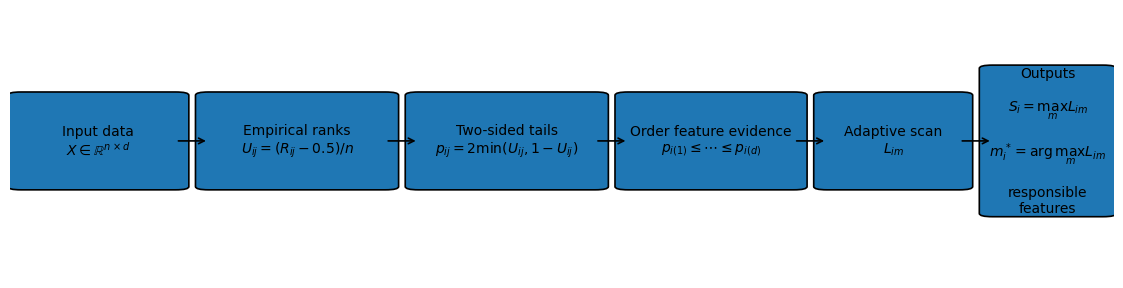

In [11]:
fig = plt.figure(
    figsize=(11.5, 3.2)
)

ax = fig.add_axes([
    0.02,
    0.08,
    0.96,
    0.84,
])

ax.set_axis_off()

steps = [
    (
        0.01,
        0.34,
        0.14,
        0.34,
        "Input data\n$X\\in\\mathbb{R}^{n\\times d}$",
    ),
    (
        0.18,
        0.34,
        0.16,
        0.34,
        "Empirical ranks\n$U_{ij}=(R_{ij}-0.5)/n$",
    ),
    (
        0.37,
        0.34,
        0.16,
        0.34,
        "Two-sided tails\n$p_{ij}=2\\min(U_{ij},1-U_{ij})$",
    ),
    (
        0.56,
        0.34,
        0.15,
        0.34,
        "Order feature evidence\n$p_{i(1)}\\leq\\cdots\\leq p_{i(d)}$",
    ),
    (
        0.74,
        0.34,
        0.12,
        0.34,
        "Adaptive scan\n$L_{im}$",
    ),
    (
        0.89,
        0.24,
        0.10,
        0.54,
        "Outputs\n\n"
        "$S_i=\\max_m L_{im}$\n\n"
        "$m_i^*=\\arg\\max_m L_{im}$\n\n"
        "responsible\nfeatures",
    ),
]

for x, y, w, h, text in steps:
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.012",
        linewidth=1.2,
    )
    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
    )

for left, right in zip(
    steps[:-1],
    steps[1:],
):
    x1 = left[0] + left[2]
    y1 = left[1] + left[3] / 2

    x2 = right[0]
    y2 = right[1] + right[3] / 2

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.2,
        },
    )

ax.set_xlim(
    0,
    1,
)
ax.set_ylim(
    0,
    1,
)

save_publication_figure(
    fig,
    "Figure_1_AETS_workflow",
)

plt.show()



## Figure 2a. Dataset-wise AP differences

For each real dataset,

\[
\Delta\mathrm{AP}
=
\mathrm{AP}_{\mathrm{AETS}}
-
\mathrm{AP}_{\mathrm{competitor}}.
\]

Positive values favor AETS. The figure compares AETS with IForest and ECOD, the two most important reference methods in the aggregate analysis.


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_2a_datasetwise_AP_differences.pdf
Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_2a_datasetwise_AP_differences.png


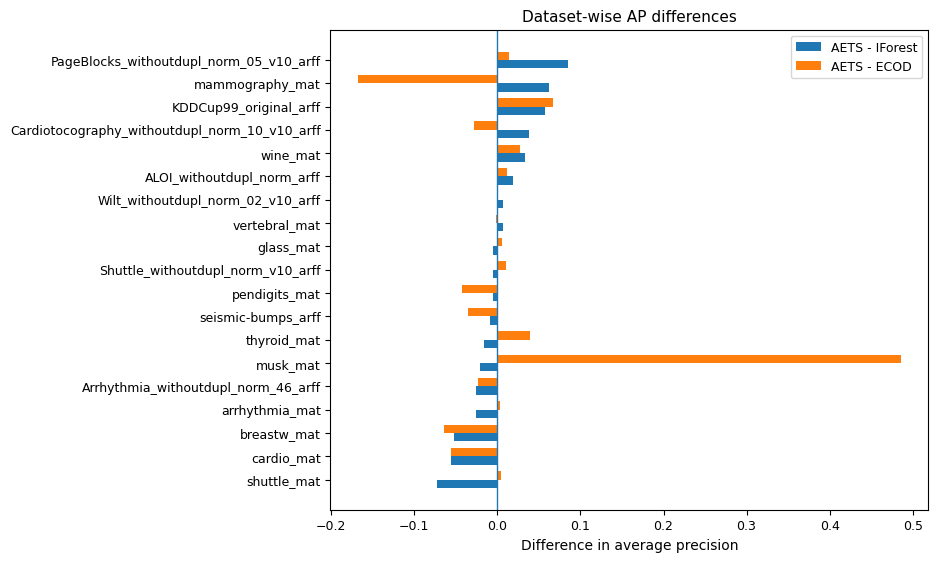

In [12]:
if len(results) == 0:
    raise RuntimeError(
        "Run the real-data benchmark cells above before producing figures."
    )

ap_pivot = results.pivot(
    index="dataset",
    columns="method",
    values="AP",
)

required = {
    "AETS",
    "IForest",
    "ECOD",
}

missing = required.difference(
    ap_pivot.columns
)

if missing:
    raise KeyError(
        f"Missing AP results for: {sorted(missing)}"
    )

ap_diff = pd.DataFrame(
    index=ap_pivot.index
)

ap_diff[
    "AETS - IForest"
] = (
    ap_pivot["AETS"]
    - ap_pivot["IForest"]
)

ap_diff[
    "AETS - ECOD"
] = (
    ap_pivot["AETS"]
    - ap_pivot["ECOD"]
)

# Sort by AETS advantage over IForest for a stable, readable order.
ap_diff = ap_diff.sort_values(
    "AETS - IForest",
    ascending=True,
)

y = np.arange(
    len(ap_diff)
)

height = 0.36

fig = plt.figure(
    figsize=(9.2, 6.0)
)

ax = fig.add_axes([
    0.31,
    0.12,
    0.65,
    0.80,
])

ax.barh(
    y - height / 2,
    ap_diff[
        "AETS - IForest"
    ].to_numpy(),
    height=height,
    label="AETS - IForest",
)

ax.barh(
    y + height / 2,
    ap_diff[
        "AETS - ECOD"
    ].to_numpy(),
    height=height,
    label="AETS - ECOD",
)

ax.axvline(
    0,
    linewidth=1.0,
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    ap_diff.index
)

ax.set_xlabel(
    "Difference in average precision"
)

ax.set_title(
    "Dataset-wise AP differences"
)

ax.legend()

save_publication_figure(
    fig,
    "Figure_2a_datasetwise_AP_differences",
)

plt.show()



## Figure 2b. Dataset-wise ROC-AUC differences

For each real dataset,

\[
\Delta\mathrm{ROC}
=
\mathrm{ROC}_{\mathrm{AETS}}
-
\mathrm{ROC}_{\mathrm{competitor}}.
\]

Positive values favor AETS.


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_2b_datasetwise_ROC_differences.pdf
Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_2b_datasetwise_ROC_differences.png


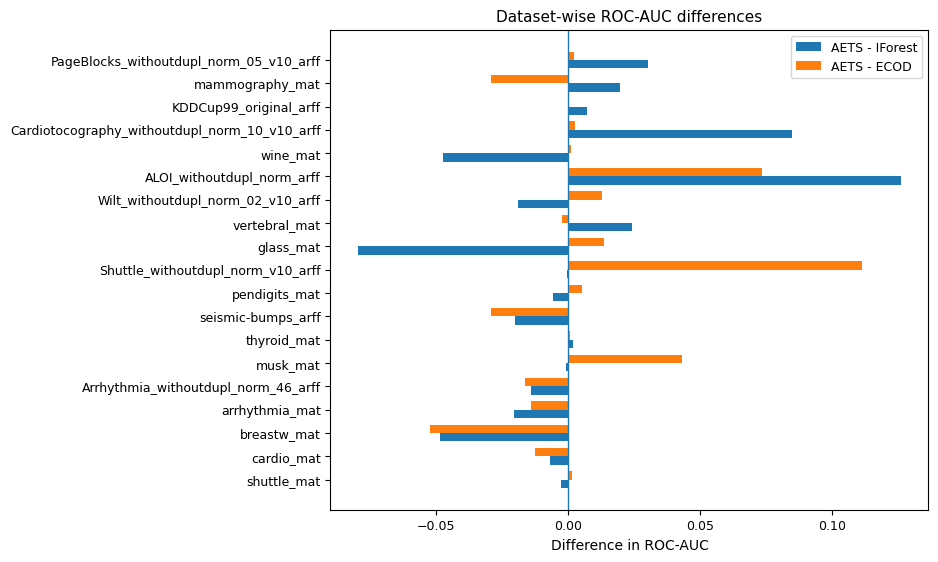

In [13]:
roc_pivot = results.pivot(
    index="dataset",
    columns="method",
    values="ROC_AUC",
)

missing = required.difference(
    roc_pivot.columns
)

if missing:
    raise KeyError(
        f"Missing ROC-AUC results for: {sorted(missing)}"
    )

roc_diff = pd.DataFrame(
    index=roc_pivot.index
)

roc_diff[
    "AETS - IForest"
] = (
    roc_pivot["AETS"]
    - roc_pivot["IForest"]
)

roc_diff[
    "AETS - ECOD"
] = (
    roc_pivot["AETS"]
    - roc_pivot["ECOD"]
)

roc_diff = roc_diff.loc[
    ap_diff.index
]

y = np.arange(
    len(roc_diff)
)

height = 0.36

fig = plt.figure(
    figsize=(9.2, 6.0)
)

ax = fig.add_axes([
    0.31,
    0.12,
    0.65,
    0.80,
])

ax.barh(
    y - height / 2,
    roc_diff[
        "AETS - IForest"
    ].to_numpy(),
    height=height,
    label="AETS - IForest",
)

ax.barh(
    y + height / 2,
    roc_diff[
        "AETS - ECOD"
    ].to_numpy(),
    height=height,
    label="AETS - ECOD",
)

ax.axvline(
    0,
    linewidth=1.0,
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    roc_diff.index
)

ax.set_xlabel(
    "Difference in ROC-AUC"
)

ax.set_title(
    "Dataset-wise ROC-AUC differences"
)

ax.legend()

save_publication_figure(
    fig,
    "Figure_2b_datasetwise_ROC_differences",
)

plt.show()



## Figure 3. Mean running-time comparison

The plot uses a logarithmic horizontal axis because the benchmark runtimes span several orders of magnitude. The values are calculated directly from the same `results` table used for the manuscript's aggregate running-time results.


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_3_mean_runtime_logscale.pdf
Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_3_mean_runtime_logscale.png


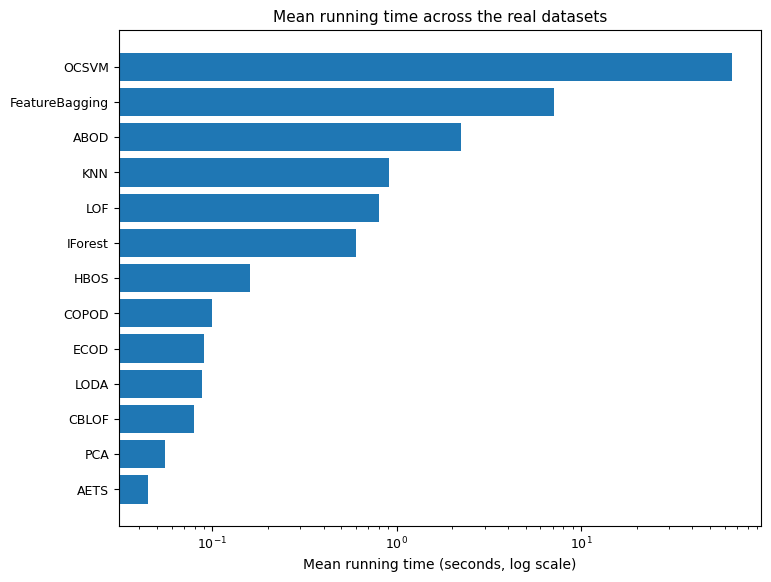

,method,mean_time_sec,median_time_sec,total_time_sec
1,AETS,0.044757,0.006723,0.850381
12,PCA,0.055226,0.006482,1.049294
2,CBLOF,0.079206,0.014874,1.504915
9,LODA,0.087464,0.064478,1.661821
4,ECOD,0.090208,0.006873,1.713950
3,COPOD,0.099620,0.007795,1.892788
6,HBOS,0.159018,0.004828,3.021334
7,IForest,0.599845,0.398626,11.397049
10,LOF,0.801238,0.085718,15.223513
8,KNN,0.900840,0.090299,17.115963


In [14]:
runtime_summary = (
    results
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        mean_time_sec=(
            "time_sec",
            "mean",
        ),
        median_time_sec=(
            "time_sec",
            "median",
        ),
        total_time_sec=(
            "time_sec",
            "sum",
        ),
    )
    .sort_values(
        "mean_time_sec",
        ascending=True,
    )
)

fig = plt.figure(
    figsize=(8.8, 6.2)
)

ax = fig.add_axes([
    0.22,
    0.12,
    0.73,
    0.80,
])

ax.barh(
    runtime_summary[
        "method"
    ],
    runtime_summary[
        "mean_time_sec"
    ],
)

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "Mean running time (seconds, log scale)"
)

ax.set_title(
    "Mean running time across the real datasets"
)

save_publication_figure(
    fig,
    "Figure_3_mean_runtime_logscale",
)

plt.show()

display(
    runtime_summary
)



## Figure 4. Synthetic validation of the effective anomaly dimension

This experiment evaluates the interpretation of

\[
m_i^\star
=
\arg\max_m L_{im}
\]

as an **effective anomaly dimension**.

For every true anomaly dimension \(s\), a fresh synthetic dataset is generated with:

- 2,000 nominal observations;
- 100 anomalous observations;
- \(d=100\) total features;
- independent standard-normal nominal coordinates;
- a mean shift of 4 standard deviations in exactly \(s\) coordinates of each anomalous observation.

The AETS formula is not changed.

For each setting, the experiment is repeated with independent random seeds. The figure shows the median selected \(m^\star\) among true anomalies, together with its interquartile range.

This synthetic experiment is separate from the real-data benchmark and therefore does not change any real-data results.


In [15]:
# ================================================================
# SYNTHETIC INTERPRETABILITY EXPERIMENT
# ================================================================

SYNTHETIC_SEED = 20260810

SYNTHETIC_N_INLIERS = 2000
SYNTHETIC_N_OUTLIERS = 100
SYNTHETIC_D = 100
SYNTHETIC_SHIFT = 4.0
SYNTHETIC_REPETITIONS = 20

TRUE_ANOMALY_DIMENSIONS = [
    1,
    2,
    5,
    10,
    20,
    30,
    40,
]


def simulate_sparse_feature_anomalies(
    rng,
    n_inliers,
    n_outliers,
    d,
    s,
    shift,
):
    """
    Independent Gaussian reference model with anomalies shifted
    in exactly s coordinates.
    """
    X_in = rng.normal(
        size=(
            n_inliers,
            d,
        )
    )

    X_out = rng.normal(
        size=(
            n_outliers,
            d,
        )
    )

    X_out[
        :,
        :s,
    ] += shift

    X = np.vstack([
        X_in,
        X_out,
    ])

    y = np.concatenate([
        np.zeros(
            n_inliers,
            dtype=int,
        ),
        np.ones(
            n_outliers,
            dtype=int,
        ),
    ])

    return X, y


synthetic_rows = []

seed_sequence = np.random.SeedSequence(
    SYNTHETIC_SEED
)

child_seeds = seed_sequence.spawn(
    len(
        TRUE_ANOMALY_DIMENSIONS
    )
    * SYNTHETIC_REPETITIONS
)

seed_index = 0

for s in TRUE_ANOMALY_DIMENSIONS:

    for rep in range(
        SYNTHETIC_REPETITIONS
    ):

        rng = np.random.default_rng(
            child_seeds[
                seed_index
            ]
        )

        seed_index += 1

        X_syn, y_syn = (
            simulate_sparse_feature_anomalies(
                rng=rng,
                n_inliers=SYNTHETIC_N_INLIERS,
                n_outliers=SYNTHETIC_N_OUTLIERS,
                d=SYNTHETIC_D,
                s=s,
                shift=SYNTHETIC_SHIFT,
            )
        )

        # No scaling is necessary because AETS is rank based.
        aets_syn = compute_aets(
            X_syn
        )

        anomaly_m = aets_syn[
            "winning_m"
        ][
            y_syn == 1
        ]

        ap_syn, roc_syn = evaluate_score(
            y_syn,
            aets_syn[
                "score"
            ],
        )

        synthetic_rows.append({
            "true_anomaly_dimension": s,
            "repetition": rep,
            "median_selected_m": float(
                np.median(
                    anomaly_m
                )
            ),
            "mean_selected_m": float(
                np.mean(
                    anomaly_m
                )
            ),
            "AP": ap_syn,
            "ROC_AUC": roc_syn,
        })


synthetic_results = pd.DataFrame(
    synthetic_rows
)

synthetic_results.to_csv(
    FIGURE_DIR
    / "Figure_4_synthetic_interpretability_results.csv",
    index=False,
)

synthetic_summary = (
    synthetic_results
    .groupby(
        "true_anomaly_dimension",
        as_index=False,
    )
    .agg(
        median_selected_m=(
            "median_selected_m",
            "median",
        ),
        q25_selected_m=(
            "median_selected_m",
            lambda x: np.quantile(
                x,
                0.25,
            ),
        ),
        q75_selected_m=(
            "median_selected_m",
            lambda x: np.quantile(
                x,
                0.75,
            ),
        ),
        mean_AP=(
            "AP",
            "mean",
        ),
        mean_ROC_AUC=(
            "ROC_AUC",
            "mean",
        ),
    )
)

display(
    synthetic_summary
)


,true_anomaly_dimension,median_selected_m,q25_selected_m,q75_selected_m,mean_AP,mean_ROC_AUC
0,1,12.0,11.000,12.500,0.061096,0.555412
1,2,13.0,10.875,13.500,0.080279,0.626362
2,5,15.5,15.000,16.000,0.188071,0.785034
3,10,19.0,19.000,19.625,0.625069,0.954247
4,20,27.5,27.000,28.000,0.997615,0.999872
5,30,36.0,35.000,36.000,1.000000,1.000000
6,40,44.0,43.750,44.000,1.000000,1.000000


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_4_effective_anomaly_dimension.pdf
Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\AETS 19 Datasets\aets_results\figures\Figure_4_effective_anomaly_dimension.png


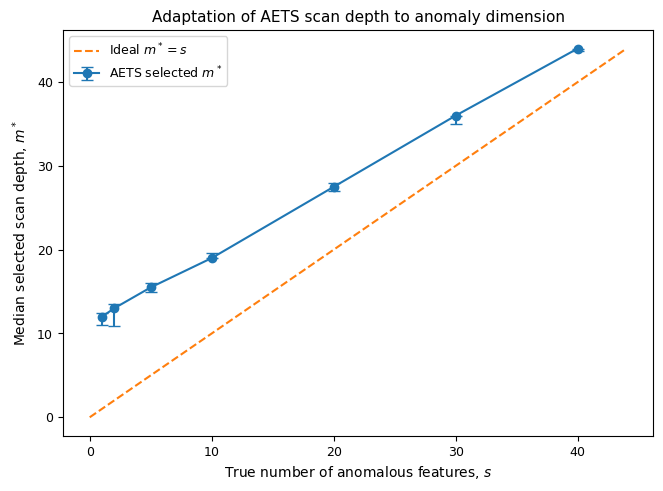

In [16]:
x = synthetic_summary[
    "true_anomaly_dimension"
].to_numpy(
    dtype=float
)

y = synthetic_summary[
    "median_selected_m"
].to_numpy(
    dtype=float
)

lower = (
    y
    - synthetic_summary[
        "q25_selected_m"
    ].to_numpy(
        dtype=float
    )
)

upper = (
    synthetic_summary[
        "q75_selected_m"
    ].to_numpy(
        dtype=float
    )
    - y
)

fig = plt.figure(
    figsize=(7.2, 5.2)
)

ax = fig.add_axes([
    0.14,
    0.14,
    0.82,
    0.78,
])

ax.errorbar(
    x,
    y,
    yerr=np.vstack([
        lower,
        upper,
    ]),
    marker="o",
    capsize=4,
    label="AETS selected $m^*$",
)

reference_max = max(
    float(
        np.max(x)
    ),
    float(
        np.max(y)
    ),
)

ax.plot(
    [
        0,
        reference_max,
    ],
    [
        0,
        reference_max,
    ],
    linestyle="--",
    label="Ideal $m^*=s$",
)

ax.set_xlabel(
    "True number of anomalous features, $s$"
)

ax.set_ylabel(
    "Median selected scan depth, $m^*$"
)

ax.set_title(
    "Adaptation of AETS scan depth to anomaly dimension"
)

ax.legend()

save_publication_figure(
    fig,
    "Figure_4_effective_anomaly_dimension",
)

plt.show()



## Optional Figure 5. Explain one real observation

The helper below can produce a publication figure for a **pre-specified** real observation. It does not automatically select a favorable example using the labels.

The upper-level interpretation is:

- ordered empirical tail probabilities show which features provide the strongest marginal evidence;
- the AETS scan profile shows where the score is maximized;
- \(m^\star\) marks the estimated effective anomaly dimension.

Set `EXPLANATION_DATASET_FILENAME` and `EXPLANATION_ROW_INDEX` before running the final cell.


In [17]:
def compute_aets_full_profile(X):
    """
    Compute the original AETS score while retaining the ordered
    feature evidence and the complete scan profile for interpretation.
    """
    X = np.asarray(
        X,
        dtype=float,
    )

    n, d = X.shape

    P = empirical_two_sided_tail_pvalues(
        X
    )

    order = np.argsort(
        P,
        axis=1,
    )

    P_sorted = np.take_along_axis(
        P,
        order,
        axis=1,
    )

    if d == 1:
        scan = (
            -np.log(
                P_sorted[:, :1]
            )
        )

        winning_idx = np.zeros(
            n,
            dtype=int,
        )

    else:
        m_max = max(
            1,
            d // 2,
        )

        m = np.arange(
            1,
            m_max + 1,
            dtype=float,
        )

        q = (
            m / d
        )

        observed = P_sorted[
            :,
            :m_max
        ]

        kl = bernoulli_kl(
            q[None, :],
            observed,
        )

        direction = np.sign(
            q[None, :]
            - observed
        )

        scan = (
            direction
            * np.sqrt(
                np.maximum(
                    2.0
                    * d
                    * kl,
                    0.0,
                )
            )
        )

        winning_idx = np.argmax(
            scan,
            axis=1,
        )

    return {
        "tail_pvalues": P,
        "ordered_feature_indices": order,
        "ordered_tail_pvalues": P_sorted,
        "scan_profile": scan,
        "winning_m": winning_idx + 1,
    }


# Set these manually for a pre-specified example.
EXPLANATION_DATASET_FILENAME = None
EXPLANATION_ROW_INDEX = None

if (
    EXPLANATION_DATASET_FILENAME is None
    or EXPLANATION_ROW_INDEX is None
):
    print(
        "Optional Figure 5 skipped. "
        "Set EXPLANATION_DATASET_FILENAME and EXPLANATION_ROW_INDEX "
        "to a pre-specified observation."
    )
else:
    explanation_path = (
        DATA_DIR
        / EXPLANATION_DATASET_FILENAME
    )

    X_exp, y_exp = load_dataset(
        explanation_path
    )

    Z_exp = preprocess_X(
        X_exp,
        SCALING,
    )

    profile = compute_aets_full_profile(
        Z_exp
    )

    i = int(
        EXPLANATION_ROW_INDEX
    )

    d_exp = Z_exp.shape[1]

    m_max = profile[
        "scan_profile"
    ].shape[1]

    m_axis = np.arange(
        1,
        m_max + 1,
    )

    m_star = int(
        profile[
            "winning_m"
        ][i]
    )

    # Figure 5a: ordered feature-tail evidence.
    fig = plt.figure(
        figsize=(7.2, 4.8)
    )

    ax = fig.add_axes([
        0.14,
        0.15,
        0.82,
        0.76,
    ])

    feature_axis = np.arange(
        1,
        d_exp + 1,
    )

    ax.plot(
        feature_axis,
        profile[
            "ordered_tail_pvalues"
        ][i],
        marker="o",
    )

    ax.axvline(
        m_star,
        linestyle="--",
        label=f"$m^*={m_star}$",
    )

    ax.set_xlabel(
        "Ordered feature index"
    )

    ax.set_ylabel(
        "Two-sided empirical tail probability"
    )

    ax.set_title(
        "Ordered feature-tail evidence for one observation"
    )

    ax.legend()

    save_publication_figure(
        fig,
        "Figure_5a_real_observation_tail_profile",
    )

    plt.show()

    # Figure 5b: AETS scan profile.
    fig = plt.figure(
        figsize=(7.2, 4.8)
    )

    ax = fig.add_axes([
        0.14,
        0.15,
        0.82,
        0.76,
    ])

    ax.plot(
        m_axis,
        profile[
            "scan_profile"
        ][i],
        marker="o",
    )

    ax.axvline(
        m_star,
        linestyle="--",
        label=f"$m^*={m_star}$",
    )

    ax.set_xlabel(
        "Scan depth, $m$"
    )

    ax.set_ylabel(
        "AETS scan statistic, $L_{im}$"
    )

    ax.set_title(
        "AETS scan profile for one observation"
    )

    ax.legend()

    save_publication_figure(
        fig,
        "Figure_5b_real_observation_scan_profile",
    )

    plt.show()

    responsible_features = profile[
        "ordered_feature_indices"
    ][
        i,
        :m_star,
    ]

    print(
        "Responsible zero-based feature indices:",
        responsible_features.tolist(),
    )

    print(
        "Ground-truth label (evaluation only):",
        int(
            y_exp[i]
        ),
    )


Optional Figure 5 skipped. Set EXPLANATION_DATASET_FILENAME and EXPLANATION_ROW_INDEX to a pre-specified observation.



## Figure files produced

After running the notebook, the publication-ready files are stored in `aets_results/figures/`.

Recommended manuscript figures:

- `Figure_1_AETS_workflow.pdf`
- `Figure_2a_datasetwise_AP_differences.pdf`
- `Figure_2b_datasetwise_ROC_differences.pdf`
- `Figure_3_mean_runtime_logscale.pdf`
- `Figure_4_effective_anomaly_dimension.pdf`

Equivalent 300-dpi PNG files are saved automatically.

Figure 5 is optional and is generated only after a real dataset filename and row index are specified manually.
